<a href="https://colab.research.google.com/github/alfinoktviaan/DataScience_240401010282_AlfinOktavian/blob/main/Pertemuan10_AlfinOktavian_240401010282.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: Alfin Oktavian

NIM: 240401010282

Kelas: IF 403

In [21]:
from google.colab import files
import pandas as pd

# Upload dataset
uploaded = files.upload()

# Mengambil nama file yang di-upload secara otomatis
nama_file = list(uploaded.keys())[0]

print("Nama file:", nama_file)

# Membaca dataset
df = pd.read_csv(nama_file)

# Melihat ukuran dataset
print("\nUkuran Dataset:")
print(df.shape)

# Melihat 5 data pertama
print("\n5 Data Pertama:")
display(df.head())

# Informasi dataset
print("\nInformasi Dataset:")
df.info()

# Proporsi kelas Churn
print("\nProporsi Churn:")
print(df["Churn"].value_counts(normalize=True))

Saving WA_Fn-UseC_-Telco-Customer-Churn (1).csv to WA_Fn-UseC_-Telco-Customer-Churn (1) (1).csv
Nama file: WA_Fn-UseC_-Telco-Customer-Churn (1) (1).csv

Ukuran Dataset:
(7043, 21)

5 Data Pertama:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

In [22]:
# ============================================================
# LANGKAH 2 - PREPROCESSING
# ============================================================

# Mengubah TotalCharges menjadi numerik
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Menghapus data yang memiliki missing value
df = df.dropna()

# Menghapus customerID karena tidak digunakan sebagai fitur
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# Mengubah target Churn menjadi numerik
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# One Hot Encoding untuk fitur kategorikal
df = pd.get_dummies(
    df,
    drop_first=True
)

# Memisahkan fitur dan target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("\nUkuran X:", X.shape)
print("Ukuran y:", y.shape)

print("\nJumlah NaN pada X:", X.isna().sum().sum())
print("Jumlah NaN pada y:", y.isna().sum())


# ============================================================
# TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nData Latih:", X_tr.shape)
print("Data Uji:", X_te.shape)


Ukuran X: (7032, 30)
Ukuran y: (7032,)

Jumlah NaN pada X: 0
Jumlah NaN pada y: 0

Data Latih: (5625, 30)
Data Uji: (1407, 30)


In [23]:
# ============================================================
# LANGKAH 3 - LATIH MODEL RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

# Melatih model
rf.fit(X_tr, y_tr)

print("\nModel Random Forest berhasil dilatih.")


Model Random Forest berhasil dilatih.



Contoh probabilitas churn:
[0.01       0.7        0.01666667 0.04579296 0.15666667 0.22666667
 0.02       0.2        0.70333333 0.        ]

Contoh hasil prediksi:
[0 1 0 0 0 0 0 0 1 0]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Tidak Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8198746188610092

METRIK EVALUASI
Accuracy : 0.7875
Precision: 0.6271
Recall   : 0.4947
F1-Score : 0.5531
ROC-AUC  : 0.8199

CONFUSION MATRIX
[[923 110]
 [189 185]]


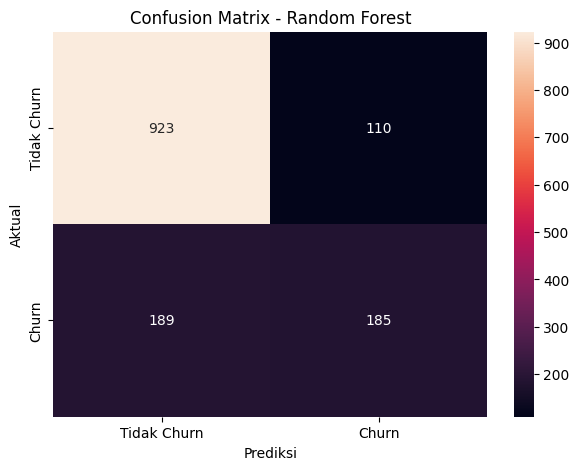

In [25]:
# ============================================================
# LANGKAH 4 - PREDIKSI
# ============================================================

# Prediksi probabilitas churn
proba = rf.predict_proba(X_te)[:, 1]

# Prediksi kelas
pred = (proba >= 0.5).astype(int)

print("\nContoh probabilitas churn:")
print(proba[:10])

print("\nContoh hasil prediksi:")
print(pred[:10])


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

print("\n==========================================")
print("CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_te,
        pred,
        target_names=["Tidak Churn", "Churn"]
    )
)


# ============================================================
# ROC-AUC
# ============================================================

roc_auc = roc_auc_score(
    y_te,
    proba
)

print("ROC-AUC:", roc_auc)


# ============================================================
# ACCURACY, PRECISION, RECALL, F1-SCORE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_te, pred)

precision = precision_score(
    y_te,
    pred,
    zero_division=0
)

recall = recall_score(
    y_te,
    pred,
    zero_division=0
)

f1 = f1_score(
    y_te,
    pred,
    zero_division=0
)

print("\n==========================================")
print("METRIK EVALUASI")
print("==========================================")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))


# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_te,
    pred
)

print("\n==========================================")
print("CONFUSION MATRIX")
print("==========================================")

print(cm)


# ============================================================
# CONFUSION MATRIX - HEATMAP
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Tidak Churn", "Churn"],
    yticklabels=["Tidak Churn", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()


In [26]:
# ============================================================
# LANGKAH 5 - PREDIKSI PROBABILITAS CHURN
# ============================================================

probabilitas_churn = pd.DataFrame({
    "Probabilitas_Churn": proba
})

print("\n==========================================")
print("PROBABILITAS CHURN")
print("==========================================")

print(
    probabilitas_churn.head(10)
)


PROBABILITAS CHURN
   Probabilitas_Churn
0            0.010000
1            0.700000
2            0.016667
3            0.045793
4            0.156667
5            0.226667
6            0.020000
7            0.200000
8            0.703333
9            0.000000


### Kesimpulan Pertemuan 10

Pada pertemuan ke-10, telah dipelajari penerapan algoritma **Random Forest** untuk memprediksi **customer churn**, mulai dari preprocessing data, pembagian data training dan testing, hingga evaluasi model menggunakan **Accuracy, Precision, Recall, F1-Score, ROC-AUC, dan Confusion Matrix**.

Temuan utama menunjukkan bahwa dataset customer churn bersifat **imbalanced**, sehingga **Recall menjadi metrik yang penting** karena berfokus pada kemampuan model dalam mendeteksi pelanggan yang benar-benar akan churn. Penggunaan `class_weight="balanced"` juga membantu model memberikan perhatian lebih terhadap kelas churn.

Keterbatasannya adalah **Accuracy saja tidak cukup** untuk menggambarkan performa model pada data yang tidak seimbang. Pertanyaan yang masih dapat dikembangkan adalah bagaimana meningkatkan kemampuan model dalam mendeteksi pelanggan churn, misalnya dengan mengatur **threshold prediksi** atau mencoba metode dan algoritma lain.
